# Дополнительные данные: EMBLAS, MADOS, PLP2019 и ERA5

Исследовательские эксперименты Littora, 26.09.2026. **Операционная модель и исходный T3 не заменены.**

[Протокол](../ml/expansion/protocol.md) фиксирует модели, пороги и разделение данных. Метки разных задач сохраняются отдельно: всё наблюдённое макролиттерное загрязнение в items/km², Marine Debris на спутниковом снимке и доля пластикового покрытия в %.

MADOS не содержит пригодной геопривязки и дат отдельных кропов; независимость от MARIDA по месту/времени не доказана. Сравнение на MARIDA — development benchmark, а не новый внешний test. Test не использован для выбора гиперпараметров.

In [1]:
from pathlib import Path
import hashlib, json, platform, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=Path.cwd()
T=ROOT/'reports/expansion/tables'
F=ROOT/'reports/expansion/figures'
F.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
def read(name): return pd.read_csv(T/(name+'.csv'))
def save(name):
    plt.tight_layout();plt.savefig(F/(name+'.png'),dpi=160,bbox_inches='tight');plt.show();plt.close()
emblas=read('emblas_events_pending');plp=read('plp2019_pixel_cover');inventory=read('mados_inventory')
metrics=read('detector_metrics');intervals=read('detector_bootstrap');weather=read('weather_oof_metrics')
assert len(emblas)==302 and not emblas.t3_eligible.any()
assert len(inventory)==2803 and inventory.groupby('group').split.nunique().max()==1
display(pd.DataFrame([
    {'source':'EMBLAS','unit':'visual session','rows':len(emblas),'status':'pending coordinates; 0 T3 additions'},
    {'source':'MADOS','unit':'240×240 crop','rows':len(inventory),'status':'scene split; geotime metadata missing'},
    {'source':'PLP2019','unit':'UAV-labelled S2 pixel','rows':len(plp),'status':f'{plp.spatial_match_valid.sum()} spatial matches / 5 dates'},
    {'source':'ERA5','unit':'prior-day context','rows':len(read('era5_event_context')),'status':'74 existing events; not new density labels'}]))

,source,unit,rows,status
0,EMBLAS,visual session,302,pending coordinates; 0 T3 additions
1,MADOS,240×240 crop,2803,scene split; geotime metadata missing
2,PLP2019,UAV-labelled S2 pixel,65,63 spatial matches / 5 dates
3,ERA5,prior-day context,74,74 existing events; not new density labels


## EMBLAS: подготовлено 302 сессии, допуск в T3 пока закрыт

В [исходной Table S2](https://ars.els-cdn.com/content/image/1-s2.0-S0269749122010302-mmc2.xlsx?download=true) площадь уже есть у всех строк. Не хватает подтверждённой связи Session ID с координатами и часового пояса StartTime. Счётчики, опубликованная плотность и N/A сохранены отдельно, нулевые сессии не удалены. Шесть российских записей в Table S1 — экспедиции/программы, не шесть сессий. Проверенные источники и черновик запроса: [журнал поиска](../docs/emblas-coordinate-search.md).

,year,events,zeros,items,surveyed_area_km2,median_density
0,2017,132,8,4941,63.95148,44.153832
1,2019,170,32,2714,29.97065,36.100000


,events,zeros,area_km2
basin_sector,,,
eastern,176,28,48.97787
western,126,12,44.94426


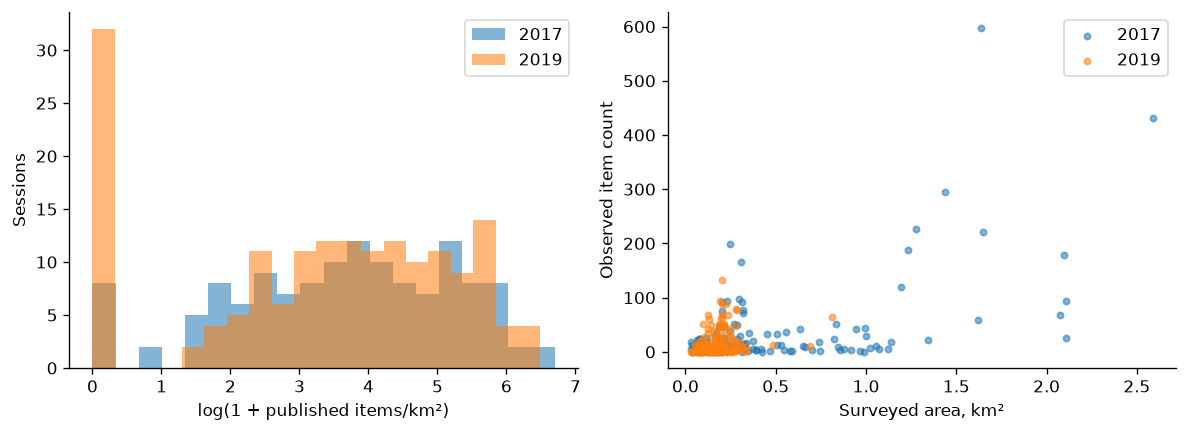

Area-weighted density: 81.50368819755181 items/km²
True observed zeros: 40


In [2]:
display(read('emblas_year_summary'))
display(emblas.groupby('basin_sector').agg(events=('event_id','size'),zeros=('is_observed_zero','sum'),area_km2=('area_km2','sum')))
fig,axs=plt.subplots(1,2,figsize=(10,3.7))
for year,g in emblas.groupby('year'):
    axs[0].hist(np.log1p(g.reported_density_items_km2),bins=20,alpha=.55,label=str(int(year)))
    axs[1].scatter(g.area_km2,g.items_count,s=14,alpha=.55,label=str(int(year)))
axs[0].set(xlabel='log(1 + published items/km²)',ylabel='Sessions');axs[0].legend()
axs[1].set(xlabel='Surveyed area, km²',ylabel='Observed item count');axs[1].legend()
save('01_emblas_effort_and_density')
print('Area-weighted density:',emblas.items_count.sum()/emblas.area_km2.sum(),'items/km²')
print('True observed zeros:',int(emblas.is_observed_zero.sum()))

## MADOS: разметка и перенос детектора

[MADOS v1](https://zenodo.org/records/10664073): исходные 174 сцены, 2803 кропа, разреженная разметка. Не размеченный класс 0 не считается водой/отрицательной меткой. Confidence 0 и невалидные спектры исключаются. Class 6 означает нефтяное пятно, class 12 — волны и следы судов; номера остальных классов нельзя безусловно переносить из MARIDA.

11 каналов rhorc объединены в физическом порядке Sentinel-2; 20/60 м увеличены nearest-neighbour. MADOS-only и joint используют одинаковый RF и подбирают порог только по MADOS validation. У прежнего детектора сохранён прежний порог MARIDA. Разности метрик отражают **обучающие данные вместе с калибровкой порога**.

Скрининг полных спектров сравнивает MADOS со всеми исходными split MARIDA; любая найденная сцена исключается целиком из эксперимента. Отсутствие точного совпадения не исключает повторную обработку или соседнюю съёмку того же события.

,split,pixels,positive_pixels,patches,scenes
0,train,761887,2561,1433,96
1,val,358121,1162,642,36
2,test,361147,973,728,42


Exact matching spectra: 0
Excluded groups: 0
Invalid labelled pixels: 0
Labelled without confidence: 0


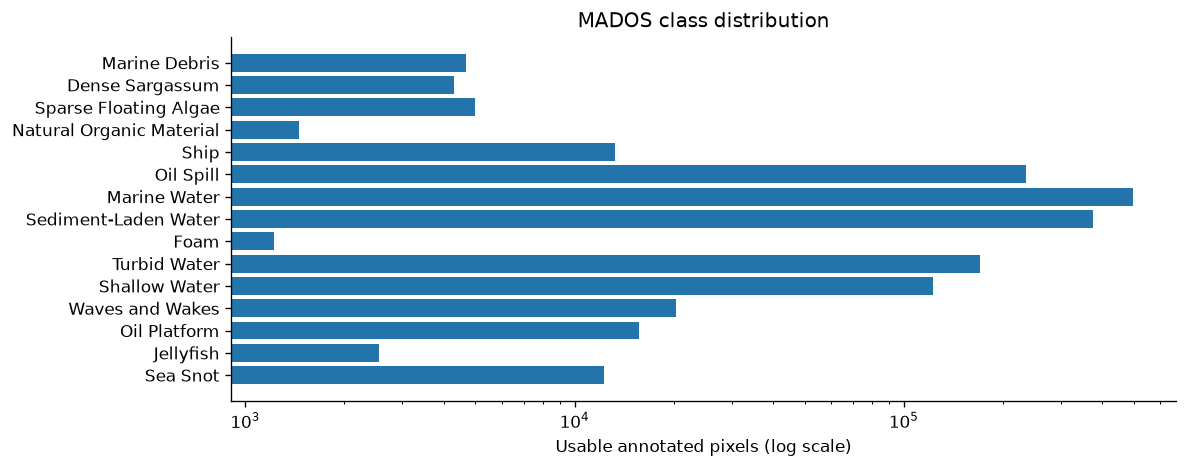

,model,threshold,selection,validation_f1
0,marida_frozen,0.631045,previous MARIDA validation,NaN
1,mados_only,0.765788,MADOS validation max F1,0.734028
2,joint,0.781313,MADOS validation max F1,0.705067


,dataset,model,pixels,positive_pixels,precision,recall,f1,iou,average_precision
0,mados_test,marida_frozen,361147,973,0.3527,0.6053,0.4457,0.2868,0.3865
1,mados_test,mados_only,361147,973,0.5373,0.5694,0.5529,0.3821,0.5594
2,mados_test,joint,361147,973,0.5538,0.5817,0.5674,0.3961,0.5729
3,marida_development_test,marida_frozen,281021,430,0.5800,0.7163,0.6410,0.4717,0.6702
4,marida_development_test,mados_only,281021,430,0.7688,0.5721,0.6560,0.4881,0.7362
5,marida_development_test,joint,281021,430,0.7441,0.6628,0.7011,0.5398,0.7614


,dataset,comparison,groups,valid_repeats,low,high,metric
0,mados_test,joint,42,1000,0.3528,0.7247,F1
1,mados_test,mados_only,42,1000,0.3397,0.7197,F1
2,mados_test,marida_frozen,42,1000,0.2159,0.6954,F1
3,mados_test,joint minus marida_frozen,42,1000,0.0007,0.1723,paired_delta_F1
4,mados_test,mados_only minus marida_frozen,42,1000,-0.0179,0.1689,paired_delta_F1
5,marida_development_test,joint,15,1000,0.6040,0.8071,F1
6,marida_development_test,mados_only,15,1000,0.5223,0.7807,F1
7,marida_development_test,marida_frozen,15,1000,0.5350,0.7605,F1
8,marida_development_test,joint minus marida_frozen,15,1000,-0.0011,0.1446,paired_delta_F1
9,marida_development_test,mados_only minus marida_frozen,15,1000,-0.0989,0.1338,paired_delta_F1


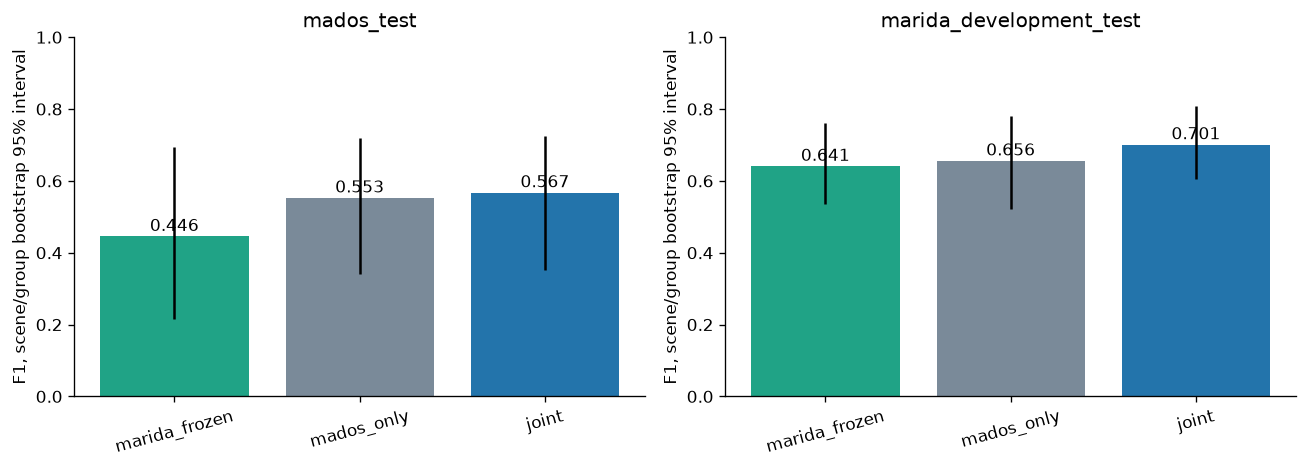

,dataset,model,class_id,pixels,predicted_debris,predicted_debris_rate
0,mados_test,marida_frozen,1,973,589,0.6053
3,mados_test,marida_frozen,4,278,19,0.0683
4,mados_test,marida_frozen,5,3574,68,0.0190
5,mados_test,marida_frozen,6,51528,0,0.0000
8,mados_test,marida_frozen,9,387,29,0.0749
11,mados_test,marida_frozen,12,6401,136,0.0212
12,mados_test,marida_frozen,13,4790,0,0.0000
15,mados_test,mados_only,1,973,554,0.5694
18,mados_test,mados_only,4,278,12,0.0432
19,mados_test,mados_only,5,3574,31,0.0087


In [3]:
display(read('mados_split_summary'))
print('Exact matching spectra:',int(inventory.marida_exact_spectral_matches.sum()))
print('Excluded groups:',inventory.loc[~inventory.cross_source_screen_pass,'group'].nunique())
print('Invalid labelled pixels:',int(inventory.invalid_labelled_pixels.sum()))
print('Labelled without confidence:',int(inventory.labelled_without_confidence.sum()))
sys.path.insert(0,str(ROOT/'ml/expansion'))
from mados import CLASSES
counts=pd.DataFrame({'class_id':list(CLASSES),'class_name':list(CLASSES.values()),
    'pixels':[int(inventory['class_'+str(k)].sum()) for k in CLASSES]})
counts.to_csv(T/'mados_class_counts.csv',index=False)
fig,ax=plt.subplots(figsize=(10,4))
ax.barh(counts.class_name,counts.pixels,color='#2374ab');ax.set_xscale('log');ax.invert_yaxis()
ax.set(xlabel='Usable annotated pixels (log scale)',title='MADOS class distribution')
save('02_mados_classes')
display(read('detector_thresholds'))
display(metrics[['dataset','model','pixels','positive_pixels','precision','recall','f1','iou','average_precision']].round(4))
display(intervals.round(4))
fig,axs=plt.subplots(1,2,figsize=(11,4))
for ax,(name,g) in zip(axs,metrics.groupby('dataset')):
    ax.bar(g.model,g.f1,color=['#20a386','#7a8a99','#2374ab'])
    for x,(_,r) in enumerate(g.iterrows()):
        ci=intervals[(intervals.dataset==name)&(intervals.comparison==r.model)].iloc[0]
        ax.vlines(x,ci.low,ci.high,color='black',lw=1.5);ax.text(x,r.f1+.015,f'{r.f1:.3f}',ha='center')
    ax.set_ylim(0,1);ax.set(title=name,ylabel='F1, scene/group bootstrap 95% interval');ax.tick_params(axis='x',rotation=15)
save('03_detector_comparison')
errors=read('detector_errors_by_class')
display(errors[(errors.dataset=='mados_test')&errors.class_id.isin([1,4,5,6,9,12,13])].round(4))

## PLP2019: покрытие пикселя, независимая дата

[PLP2019](https://zenodo.org/records/3752719) содержит 65 точек с долями материалов за пять дат. Два пикселя 18.05.2019 находятся вне допуска сопоставления с NetCDF; они сохранены с причиной исключения. Для оставшихся 63 отклонение центров менее метра. Все сохранённые l2_flags равны 0. Тростник — отдельная доля, не пластик.

Данные **rhos**, не rhorc: текущий MARIDA RF на них не применяется. Отдельная Ridge(alpha=10) с нормализацией только по train, leave-one-date-out, предсказывает процент покрытия. Контроль — среднее train-дней. Пять дат одного участка и малого числа искусственных мишеней не характеризуют весь диапазон природных условий.

,pixels,spatial_matches,mean_plastic_pct
date,,,
2019-04-18,6,6,20.000000
2019-05-03,25,25,9.680000
2019-05-18,12,10,10.083333
2019-05-28,10,10,9.800000
2019-06-07,12,12,8.250000


,date,pixel_name,match_distance_m,exclusion_reason
41,2019-05-18,A3,10.193583,outside_pixel_match_tolerance
42,2019-05-18,A4,10.146287,outside_pixel_match_tolerance


,model,pixels,dates,mae_percentage_points,r2
0,ridge_rhos,63,5,10.3560,-0.167
1,train_mean,63,5,9.8699,-0.017


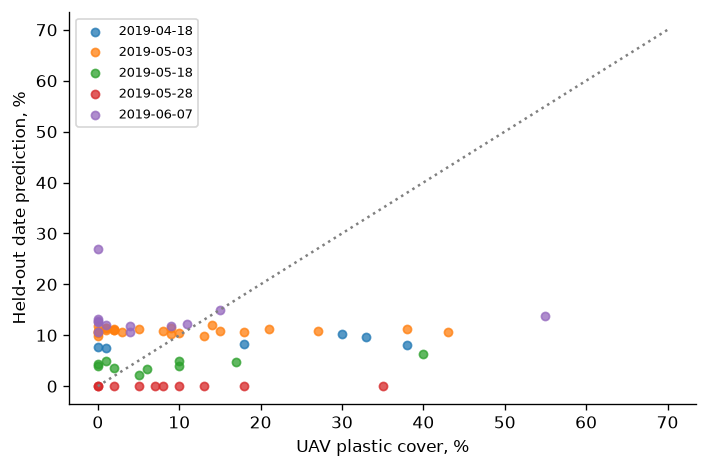

In [4]:
display(plp.groupby('date').agg(pixels=('date','size'),spatial_matches=('spatial_match_valid','sum'),mean_plastic_pct=('plastic_cover_pct','mean')))
display(plp.loc[~plp.spatial_match_valid,['date','pixel_name','match_distance_m','exclusion_reason']])
display(read('plp2019_date_holdout_metrics').round(4))
pred=read('plp2019_date_holdout_predictions')
fig,ax=plt.subplots(figsize=(6,4))
for date,g in pred[pred.model=='ridge_rhos'].groupby('date'): ax.scatter(g.observed,g.predicted,label=date,s=24,alpha=.75)
ax.plot([0,70],[0,70],':',color='gray');ax.set(xlabel='UAV plastic cover, %',ylabel='Held-out date prediction, %')
ax.legend(fontsize=8);save('04_plp_date_holdout')

## ERA5: проверка пользы погодного контекста

74 исходных визуальных события, исходные группы/folds EDA. [ERA5 через Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api): 0.25°, nearest sea grid cell, UTC; средний/максимальный ветер, средние u/v и осадки **за предшествующий календарный день**. Это не измеренные течения и не восстановленное точное время учёта.

Две фиксированные модели RF log1p: координаты + сезон и те же признаки + погода. Профили Северного и Чёрного морей оцениваются раздельно. Положительный paired MAE gain означает улучшение от погоды. Отрицательное значение означает ухудшение.

,profile,model,events,mae_items_km2,rmse_items_km2,r2
0,S3_visual_GT2,location_season,41,17.1514,34.0607,0.0452
1,S3_visual_GT2,location_season_weather,41,17.9389,35.4944,-0.0369
2,S3_visual_GT2,train_median,41,21.9073,37.6459,-0.1664
3,S4_visual_GT2_5,location_season,33,182.8170,256.3064,-0.2563
4,S4_visual_GT2_5,location_season_weather,33,204.9391,277.1517,-0.4689
5,S4_visual_GT2_5,train_median,33,180.7558,247.3584,-0.1701


,profile,mae_gain_items_km2,low,high,groups
0,S3_visual_GT2,-0.7875,-3.6886,0.0905,8
1,S4_visual_GT2_5,-22.1221,-48.6258,15.2440,9


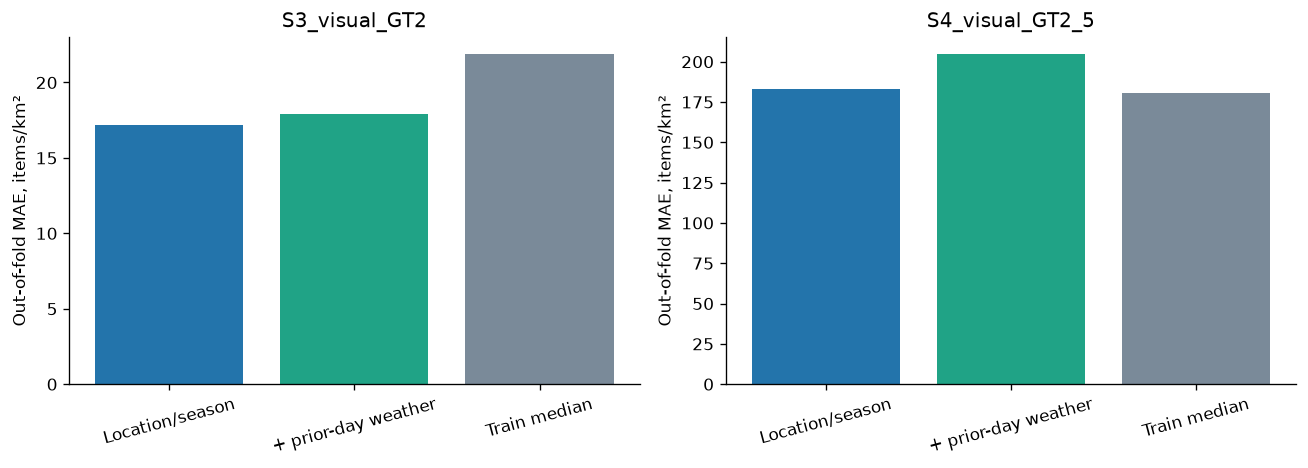

In [5]:
display(weather.round(4));display(read('weather_paired_gain').round(4))
fig,axs=plt.subplots(1,2,figsize=(11,4))
for ax,(profile,g) in zip(axs,weather.groupby('profile')):
    ax.bar(['Location/season','+ prior-day weather','Train median'],g.mae_items_km2,color=['#2374ab','#20a386','#7a8a99'])
    ax.set(title=profile,ylabel='Out-of-fold MAE, items/km²');ax.tick_params(axis='x',rotation=15)
save('05_weather_ablation')

## Выводы и необходимые данные

1. Для T3 сильнейший недостающий блок — оригинальная таблица EMBLAS `Session ID ↔ start/end/midpoint coordinates`, timezone, принадлежность экспедиции и условия повторного использования. Для спутниковых пар полезнее трек с временем, чем одна точка. Уже подготовленные 302 сессии включают 40 настоящих нулей.
2. Для проверяемого переноса MADOS нужны реальные Sentinel-2 product IDs, даты и геометрии кропов; затем общий split MARIDA/MADOS по месту и времени. Без этого совместное обучение остаётся экспериментом.
3. Для Littora L2A нужны идентичные сцены/разметка в L2A и ACOLITE rhorc, единый контроль масштаба, offset и масок. Совпадение количества каналов не обеспечивает сопоставимость продуктов.
4. Для оценки концентрации нужны новые независимые визуальные трансекты (включая нули), площадь полосы, счётчик, порог размера, усилие наблюдателя и синхронная съёмка. Пиксельная вероятность детектора и процент покрытия PLP не являются items/km².
5. Погодные признаки и PLP в проверенных простых моделях не дали подтверждённого улучшения; дальнейшую сложность следует проверять на новых группах, не подбирать по уже увиденному test. Морские течения/волны ещё не включены; windrows и другие наборы остаются отдельными кандидатами, а не выполненными экспериментами.

[Поиск EMBLAS и точный запрос владельцу](../docs/emblas-coordinate-search.md). Письма автоматически не отправлялись.

In [6]:
# Recompute saved detector decisions independently from scores.
from marida.models import confusion, scores_from_counts
thresholds=read('detector_thresholds').set_index('model').threshold
for dataset in metrics.dataset.unique():
    a=np.load(ROOT/'data/processed/expansion'/f'{dataset}_predictions.npz')
    assert (a['y']>0).all()
    for model,threshold in thresholds.items():
        c=confusion(a['y']==1,a[model+'_score']>=threshold)
        expected=metrics[(metrics.dataset==dataset)&(metrics.model==model)].iloc[0]
        assert all(c[k]==expected[k] for k in ['tp','fp','fn','tn'])
        assert np.isclose(scores_from_counts(**c)['f1'],expected.f1)
files=sorted(T.glob('*.csv'))+[ROOT/'ml/expansion/protocol.md',ROOT/'data/case/macroplastic_marine_samples.csv']
hashes=[{'path':str(p.relative_to(ROOT)),'sha256':hashlib.sha256(p.read_bytes()).hexdigest()} for p in files if p.name!='artifact_hashes.csv']
pd.DataFrame(hashes).to_csv(T/'artifact_hashes.csv',index=False)
summary={'emblas_sessions':len(emblas),'emblas_zeros':int(emblas.is_observed_zero.sum()),'t3_added':0,
         'mados_patches':len(inventory),'mados_scenes':inventory.scene_id.nunique(),
         'mados_usable_pixels':int(inventory.usable_pixels.sum()),
         'cross_source_matching_spectra':int(inventory.marida_exact_spectral_matches.sum()),
         'cross_source_excluded_groups':inventory.loc[~inventory.cross_source_screen_pass,'group'].nunique(),
         'plp_pixels':len(plp),'plp_matched_pixels':int(plp.spatial_match_valid.sum()),
         'detector_metrics':metrics.to_dict('records'),'weather_metrics':weather.to_dict('records'),
         'python':sys.version,'platform':platform.platform(),'production_model_changed':False}
(ROOT/'reports/expansion/summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2))
print('Saved predictions reproduce all detector confusion matrices and F1 values. Report complete.')

Saved predictions reproduce all detector confusion matrices and F1 values. Report complete.
